In [1]:
import sympy as sp
from sympy import sin, cos, pi

# Inisialisasi pretty printing agar output matriks mudah dibaca
sp.init_printing(use_unicode=True)

# -------------------------------------------------------------------
# Mendefinisikan Variabel Simbolis
# -------------------------------------------------------------------
# Definisikan variabel sudut sendi dasar
theta1, theta2, theta3, theta4, theta5, theta6 = sp.symbols('theta1:7')

# Definisikan simbol ringkas untuk cosinus dan sinus
C1, C2, C3, C4, C5, C6 = sp.symbols('C1:7')
S1, S2, S3, S4, S5, S6 = sp.symbols('S1:7')

# Definisikan simbol derivatif menggunakan Unicode (dot notation)
θ̇1, θ̇2, θ̇3, θ̇4, θ̇5, θ̇6 = sp.symbols('θ̇1:7')
θ̈1, θ̈2, θ̈3, θ̈4, θ̈5, θ̈6 = sp.symbols('θ̈1:7')

# Buat dictionary untuk substitusi agar tampilan menjadi ringkas
# Ini akan mengganti cos(theta1) -> C1, sin(theta1) -> S1, dst.
subs_dict = {
    cos(theta1): C1, sin(theta1): S1,
    cos(theta2): C2, sin(theta2): S2,
    cos(theta3): C3, sin(theta3): S3,
    cos(theta4): C4, sin(theta4): S4,
    cos(theta5): C5, sin(theta5): S5,
    cos(theta6): C6, sin(theta6): S6,
}


### Rotation Matrices

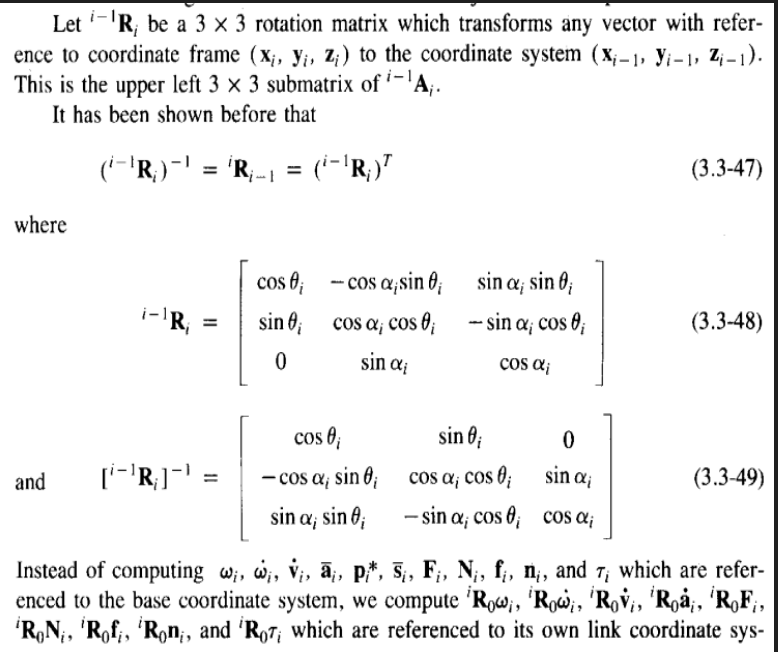

In [2]:
# -------------------------------------------------------------------
# Fungsi Bantuan untuk Rotasi
# -------------------------------------------------------------------
# Kita buat fungsi untuk menghasilkan matriks rotasi dasar dari sudut Roll (x), Pitch (y), dan Yaw (z).

def rot_x(angle):
    return sp.Matrix([
        [1, 0, 0],
        [0, cos(angle), -sin(angle)],
        [0, sin(angle), cos(angle)]
    ])

def rot_y(angle):
    return sp.Matrix([
        [cos(angle), 0, sin(angle)],
        [0, 1, 0],
        [-sin(angle), 0, cos(angle)]
    ])

def rot_z(angle):
    return sp.Matrix([
        [cos(angle), -sin(angle), 0],
        [sin(angle), cos(angle), 0],
        [0, 0, 1]
    ])

def rpy_to_rot_matrix(roll, pitch, yaw):
    # Konvensi ZYX untuk RPY
    return rot_z(yaw) * rot_y(pitch) * rot_x(roll)

# -------------------------------------------------------------------
# Menghitung Matriks Rotasi i-1_R_i
# -------------------------------------------------------------------
# Kita akan membentuk setiap matriks rotasi i-1_R_i. Dalam URDF, 
# transformasi total dari frame parent ke child adalah T_static * T_joint. 
# Matriks rotasi i-1_R_i adalah hasil perkalian dari rotasi statis (dari tag <origin>) 
# dan rotasi dinamis sendi (dari tag <axis>).
#
# Karena semua sendi myCobot adalah revolute di sekitar sumbu Z lokal, 
# rotasi dinamisnya selalu rot_z(theta_i).

# Data dari URDF myCobot 280 Pi
# Joint 1 (joint2_to_joint1): parent=joint1, child=joint2
R_static_01 = rpy_to_rot_matrix(0, 0, 0)
R_joint_1 = rot_z(theta1)
R01 = R_static_01 * R_joint_1
print("Matriks Rotasi 0_R_1:")
sp.pprint(R01)
print("-" * 30)


# Joint 2 (joint3_to_joint2): parent=joint2, child=joint3
R_static_12 = rpy_to_rot_matrix(0, pi/2, -pi/2)
R_joint_2 = rot_z(theta2)
R12 = R_static_12 * R_joint_2
print("Matriks Rotasi 1_R_2:")
sp.pprint(R12)
print("-" * 30)


# Joint 3 (joint4_to_joint3): parent=joint3, child=joint4
R_static_23 = rpy_to_rot_matrix(0, 0, 0)
R_joint_3 = rot_z(theta3)
R23 = R_static_23 * R_joint_3
print("Matriks Rotasi 2_R_3:")
sp.pprint(R23)
print("-" * 30)


# Joint 4 (joint5_to_joint4): parent=joint4, child=joint5
R_static_34 = rpy_to_rot_matrix(0, 0, -pi/2)
R_joint_4 = rot_z(theta4)
R34 = R_static_34 * R_joint_4
print("Matriks Rotasi 3_R_4:")
sp.pprint(R34)
print("-" * 30)


# Joint 5 (joint6_to_joint5): parent=joint5, child=joint6
R_static_45 = rpy_to_rot_matrix(pi/2, -pi/2, 0)
R_joint_5 = rot_z(theta5)
R45 = R_static_45 * R_joint_5
print("Matriks Rotasi 4_R_5:")
sp.pprint(R45)
print("-" * 30)


# Joint 6 (joint6output_to_joint6): parent=joint6, child=joint6_flange
R_static_56 = rpy_to_rot_matrix(-pi/2, 0, 0)
R_joint_6 = rot_z(theta6)
R56 = R_static_56 * R_joint_6
print("Matriks Rotasi 5_R_6:")
sp.pprint(R56)
print("-" * 30)


Matriks Rotasi 0_R_1:
⎡cos(θ₁)  -sin(θ₁)  0⎤
⎢                    ⎥
⎢sin(θ₁)  cos(θ₁)   0⎥
⎢                    ⎥
⎣   0        0      1⎦
------------------------------
Matriks Rotasi 1_R_2:
⎡sin(θ₂)   cos(θ₂)  0 ⎤
⎢                     ⎥
⎢   0         0     -1⎥
⎢                     ⎥
⎣-cos(θ₂)  sin(θ₂)  0 ⎦
------------------------------
Matriks Rotasi 2_R_3:
⎡cos(θ₃)  -sin(θ₃)  0⎤
⎢                    ⎥
⎢sin(θ₃)  cos(θ₃)   0⎥
⎢                    ⎥
⎣   0        0      1⎦
------------------------------
Matriks Rotasi 3_R_4:
⎡sin(θ₄)   cos(θ₄)  0⎤
⎢                    ⎥
⎢-cos(θ₄)  sin(θ₄)  0⎥
⎢                    ⎥
⎣   0         0     1⎦
------------------------------
Matriks Rotasi 4_R_5:
⎡-sin(θ₅)  -cos(θ₅)  0 ⎤
⎢                      ⎥
⎢   0         0      -1⎥
⎢                      ⎥
⎣cos(θ₅)   -sin(θ₅)  0 ⎦
------------------------------
Matriks Rotasi 5_R_6:
⎡cos(θ₆)   -sin(θ₆)  0⎤
⎢                     ⎥
⎢   0         0      1⎥
⎢                     ⎥
⎣-sin(θ₆)  -cos(θ₆)  0⎦
---

In [3]:
# ... (kode dari skrip sebelumnya tetap sama) ...

# -------------------------------------------------------------------
# Menghitung Matriks Invers (dengan Transpose)
# -------------------------------------------------------------------
R10 = R01.T
R21 = R12.T
R32 = R23.T
R43 = R34.T
R54 = R45.T
R65 = R56.T

print("Matriks Rotasi Invers 1_R_0:")
sp.pprint(R10)
print("-" * 30)
print("Matriks Rotasi Invers 2_R_1:")
sp.pprint(R21)
print("-" * 30)
# (Lanjutkan untuk mencetak matriks invers lainnya jika perlu)

# -------------------------------------------------------------------
# Menghitung Matriks Rotasi Total (Dasar ke Ujung)
# -------------------------------------------------------------------
# 0_R_6 = 0_R_1 * 1_R_2 * 2_R_3 * 3_R_4 * 4_R_5 * 5_R_6
R06 = R01 * R12 * R23 * R34 * R45 * R56
# Untuk menjaga ekspresi agar tidak terlalu besar, kita bisa sederhanakan
R06_simplified = sp.trigsimp(R06)

# -------------------------------------------------------------------
# Membuat Aturan Substitusi Tambahan untuk Tampilan
# -------------------------------------------------------------------
# Kita tambahkan aturan untuk kombinasi sudut agar lebih ringkas
# Anda bisa menambahkan lebih banyak kombinasi jika diperlukan
C12, S12 = sp.symbols('C12, S12')
C23, S23 = sp.symbols('C23, S23')

# Perbarui dictionary substitusi kita
# subs_dict sudah ada dari kode sebelumnya
subs_dict_total = subs_dict.copy() # Salin agar tidak mengubah yang asli
subs_dict_total.update({
    cos(theta1 + theta2): C12, sin(theta1 + theta2): S12,
    cos(theta2 + theta3): C23, sin(theta2 + theta3): S23,
    # Tambahkan kombinasi lain jika muncul di hasil penyederhanaan
})


# -------------------------------------------------------------------
# Menampilkan Hasil dengan Notasi Sangat Ringkas
# -------------------------------------------------------------------
print("Matriks Rotasi Total 0_R_6 (Notasi Ringkas):")
# Terapkan substitusi pada matriks yang sudah disederhanakan
sp.pprint(R06_simplified.subs(subs_dict_total))
print("-" * 50)

# Matriks invers totalnya adalah transpose-nya
R60_simplified = R06_simplified.T
print("Matriks Rotasi Total 6_R_0 (Notasi Ringkas):")
sp.pprint(R60_simplified.subs(subs_dict_total))
print("-" * 50)

Matriks Rotasi Invers 1_R_0:
⎡cos(θ₁)   sin(θ₁)  0⎤
⎢                    ⎥
⎢-sin(θ₁)  cos(θ₁)  0⎥
⎢                    ⎥
⎣   0         0     1⎦
------------------------------
Matriks Rotasi Invers 2_R_1:
⎡sin(θ₂)  0   -cos(θ₂)⎤
⎢                     ⎥
⎢cos(θ₂)  0   sin(θ₂) ⎥
⎢                     ⎥
⎣   0     -1     0    ⎦
------------------------------
Matriks Rotasi Total 0_R_6 (Notasi Ringkas):
⎡C₁⋅S₆⋅sin(θ₂ + θ₃ + θ₄) + C₆⋅(C₁⋅S₅⋅cos(θ₂ + θ₃ + θ₄) + C₅⋅S₁)   C₁⋅C₆⋅sin(θ₂ ↪
⎢                                                                              ↪
⎢C₆⋅(-C₁⋅C₅ + S₁⋅S₅⋅cos(θ₂ + θ₃ + θ₄)) + S₁⋅S₆⋅sin(θ₂ + θ₃ + θ₄)  C₆⋅S₁⋅sin(θ₂ ↪
⎢                                                                              ↪
⎣        C₆⋅S₅⋅sin(θ₂ + θ₃ + θ₄) - S₆⋅cos(θ₂ + θ₃ + θ₄)                   -C₆⋅ ↪

↪  + θ₃ + θ₄) - S₆⋅(C₁⋅S₅⋅cos(θ₂ + θ₃ + θ₄) + C₅⋅S₁)   C₁⋅C₅⋅cos(θ₂ + θ₃ + θ₄) ↪
↪                                                                              ↪
↪  + θ₃ + θ₄) - S₆⋅(-C₁⋅C₅ + S₁⋅

### Compute the angular velocity for revolute joint

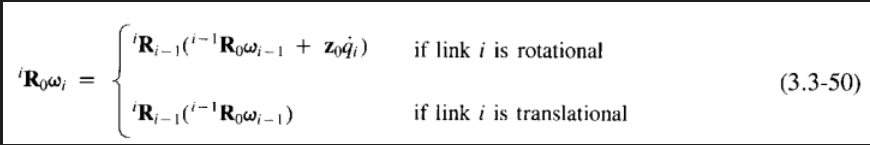

In [4]:
# -------------------------------------------------------------------
# Bagian 2: Forward Recursion - Propagasi Kecepatan & Percepatan
# -------------------------------------------------------------------
# d_theta1, d_theta2, d_theta3, d_theta4, d_theta5, d_theta6 = sp.symbols('d_theta1:7')
# dd_theta1, dd_theta2, dd_theta3, dd_theta4, dd_theta5, dd_theta6 = sp.symbols('dd_theta1:7')

# Kondisi Awal Linear (Base/Dasar)
v0 = sp.Matrix([0, 0, 0]) # Kecepatan linear dasar adalah nol

# Gravitasi (didefinisikan di frame 0)
g = sp.Symbol('g')
v_dot0 = sp.Matrix([0, 0, g]) # Percepatan gravitasi bekerja ke arah z positif di frame 0

# Vektor sumbu z (sumbu rotasi untuk semua sendi revolute)
z0 = sp.Matrix([0, 0, 1])

# Kondisi Awal (Base/Dasar)
# Kecepatan dan percepatan angular dari dasar adalah nol
w0 = sp.Matrix([0, 0, 0])
alpha0 = sp.Matrix([0, 0, 0]) # alpha adalah nama lain untuk w_dot

# --- Iterasi i = 1 ---
w1 = R10 * w0 + z0 * θ̇1
alpha1 = R10 * alpha0 + (R10 * w0).cross(z0 * θ̇1) + z0 * θ̈1

# --- Iterasi i = 2 ---
w2 = R21 * w1 + z0 * θ̇2
alpha2 = R21 * alpha1 + (R21 * w1).cross(z0 * θ̇2) + z0 * θ̈2

# --- Iterasi i = 3 ---
w3 = R32 * w2 + z0 * θ̇3
alpha3 = R32 * alpha2 + (R32 * w2).cross(z0 * θ̇3) + z0 * θ̈3

# --- Iterasi i = 4 ---
w4 = R43 * w3 + z0 * θ̇4
alpha4 = R43 * alpha3 + (R43 * w3).cross(z0 * θ̇4) + z0 * θ̈4

# --- Iterasi i = 5 ---
w5 = R54 * w4 + z0 * θ̇5
alpha5 = R54 * alpha4 + (R54 * w4).cross(z0 * θ̇5) + z0 * θ̈5

# --- Iterasi i = 6 ---
w6 = R65 * w5 + z0 * θ̇6
alpha6 = R65 * alpha5 + (R65 * w5).cross(z0 * θ̇6) + z0 * θ̈6

# -------------------------------------------------------------------
# Bagian 3: Menampilkan Hasil dengan Notasi Ringkas
# -------------------------------------------------------------------
print("="*15 + " KECEPATAN ANGULAR (w) " + "="*15)
print("w1 (Kecepatan Angular Link 1):")
sp.pprint(w1.subs(subs_dict))
print("-" * 50)

print("w2 (Kecepatan Angular Link 2):")
sp.pprint(w2.subs(subs_dict))
print("-" * 50)

# (Anda bisa melanjutkan untuk mencetak w3, w4, w5 jika perlu)

print("w6 (Kecepatan Angular Link 6 - End Effector):")
sp.pprint(w6.subs(subs_dict))
print("-" * 50)

print("\n" + "="*15 + " PERCEPATAN ANGULAR (alpha) " + "="*12)
print("alpha1 (Percepatan Angular Link 1):")
sp.pprint(alpha1.subs(subs_dict))
print("-" * 50)

print("alpha2 (Percepatan Angular Link 2):")
sp.pprint(alpha2.subs(subs_dict))
print("-" * 50)

# (Anda bisa melanjutkan untuk mencetak alpha3, alpha4, alpha5 jika perlu)

print("alpha6 (Percepatan Angular Link 6 - End Effector):")
sp.pprint(alpha6.subs(subs_dict))
print("-" * 50)




=============== KECEPATAN ANGULAR (w) ===============
w1 (Kecepatan Angular Link 1):
⎡0 ⎤
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣θ̇1⎦
--------------------------------------------------
w2 (Kecepatan Angular Link 2):
⎡-C₂⋅θ̇1⎤
⎢      ⎥
⎢S₂⋅θ̇1 ⎥
⎢      ⎥
⎣  θ̇2  ⎦
--------------------------------------------------
w6 (Kecepatan Angular Link 6 - End Effector):
⎡C₆⋅(C₅⋅(θ̇2 + θ̇3 + θ̇4) - S₅⋅(-C₄⋅(C₂⋅S₃⋅θ̇1 + C₃⋅S₂⋅θ̇1) + S₄⋅(-C₂⋅C₃⋅θ̇1 + S₂⋅S₃ ↪
⎢                                                                              ↪
⎢-C₆⋅(-C₄⋅(-C₂⋅C₃⋅θ̇1 + S₂⋅S₃⋅θ̇1) - S₄⋅(C₂⋅S₃⋅θ̇1 + C₃⋅S₂⋅θ̇1) + θ̇5) - S₆⋅(C₅⋅(θ̇2 ↪
⎢                                                                              ↪
⎣                                 -C₅⋅(-C₄⋅(C₂⋅S₃⋅θ̇1 + C₃⋅S₂⋅θ̇1) + S₄⋅(-C₂⋅C₃⋅ ↪

↪ ⋅θ̇1))) - S₆⋅(-C₄⋅(-C₂⋅C₃⋅θ̇1 + S₂⋅S₃⋅θ̇1) - S₄⋅(C₂⋅S₃⋅θ̇1 + C₃⋅S₂⋅θ̇1) + θ̇5) ⎤
↪                                                                          ⎥
↪  + θ̇3 + θ̇4) - S₅⋅(-C₄⋅(C₂⋅S₃⋅θ̇1 + C₃⋅S₂⋅θ̇1) + S₄⋅(-C₂⋅C₃⋅θ̇1 + S₂⋅S₃⋅θ̇1)))⎥

### Compute the angular acceleration for revolute joint
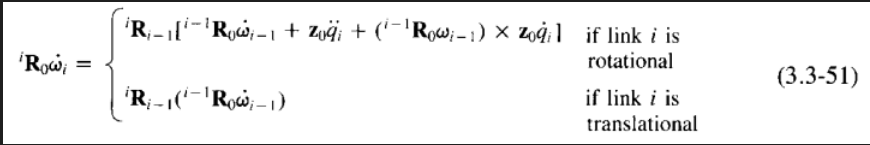

In [5]:
# -------------------------------------------------------------------
# Bagian 3: Forward Recursion - Percepatan Linear
# -------------------------------------------------------------------
# Definisikan vektor posisi p_i-1,i dari URDF (dalam meter)
p01 = sp.Matrix([0, 0, 0.13156])
p12 = sp.Matrix([0, 0, 0])
p23 = sp.Matrix([-0.1104, 0, 0])
p34 = sp.Matrix([-0.096, 0, 0.06462])
p45 = sp.Matrix([0, -0.07318, 0])
p56 = sp.Matrix([0, 0.0456, 0])

# --- Iterasi i = 1 ---
# Rumus: v_dot_i = i_R_i-1 * (v_dot_i-1 + alpha_i-1 x p_i-1,i + w_i-1 x (w_i-1 x p_i-1,i))
v_dot1 = R10 * (v_dot0 + alpha0.cross(p01) + w0.cross(w0.cross(p01)))
# --- Iterasi i = 2 ---
v_dot2 = R21 * (v_dot1 + alpha1.cross(p12) + w1.cross(w1.cross(p12)))
# --- Iterasi i = 3 ---
v_dot3 = R32 * (v_dot2 + alpha2.cross(p23) + w2.cross(w2.cross(p23)))
# --- Iterasi i = 4 ---
v_dot4 = R43 * (v_dot3 + alpha3.cross(p34) + w3.cross(w3.cross(p34)))
# --- Iterasi i = 5 ---
v_dot5 = R54 * (v_dot4 + alpha4.cross(p45) + w4.cross(w4.cross(p45)))
# --- Iterasi i = 6 ---
v_dot6 = R65 * (v_dot5 + alpha5.cross(p56) + w5.cross(w5.cross(p56)))

# -------------------------------------------------------------------
# Bagian 4: Menampilkan Hasil dengan Notasi Ringkas
# -------------------------------------------------------------------
print("="*12 + " PERCEPATAN LINEAR (v_dot) " + "="*13)
print("v_dot1 (Percepatan Linear Origin Link 1):")
sp.pprint(v_dot1.subs(subs_dict))
print("-" * 50)

print("v_dot1 (Percepatan Linear Origin Link 2):")
sp.pprint(v_dot2.subs(subs_dict))
print("-" * 50)

print("v_dot6 (Percepatan Linear Origin Link 6 - End Effector):")
sp.pprint(v_dot6.subs(subs_dict))
print("-" * 50)

============ PERCEPATAN LINEAR (v_dot) =============
v_dot1 (Percepatan Linear Origin Link 1):
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣g⎦
--------------------------------------------------
v_dot1 (Percepatan Linear Origin Link 2):
⎡-C₂⋅g⎤
⎢     ⎥
⎢S₂⋅g ⎥
⎢     ⎥
⎣  0  ⎦
--------------------------------------------------
v_dot6 (Percepatan Linear Origin Link 6 - End Effector):
⎡    ⎛                                                                         ↪
⎢ C₆⋅⎝0.0456⋅C₄⋅(C₃⋅(-C₂⋅θ̈1 + S₂⋅θ̇1⋅θ̇2) + S₃⋅(C₂⋅θ̇1⋅θ̇2 + S₂⋅θ̈1) + θ̇3⋅(C₂⋅S₃⋅θ̇1 ↪
⎢                                                                              ↪
⎢     ⎛     ⎛                                   ⎛                 2   2        ↪
⎢- C₆⋅⎝- C₄⋅⎝0.06462⋅C₃⋅(C₂⋅θ̇1⋅θ̇2 + S₂⋅θ̈1) + C₃⋅⎝-C₂⋅g + 0.1104⋅S₂ ⋅θ̇1  + 0.11 ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎣                                                                

### Calculate Linear Accel at the CoM for Links

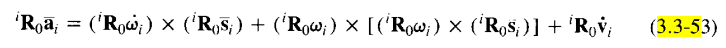

In [6]:
# -------------------------------------------------------------------
# Bagian 4: Percepatan Pusat Massa (CoM)
# -------------------------------------------------------------------

# Definisikan vektor posisi s_i dari origin frame {i} ke CoM link {i}
# Nilai ini diambil dari tag <origin xyz="..."> di dalam blok <inertial>
# setiap link pada file URDF myCobot.

# Catatan: Link di URDF diberi nama 'joint1', 'joint2', dst.
# Kita akan sebut s1, s2, ... untuk konsistensi.
s1 = sp.Matrix([0, 0, -1.5708])     # Dari link "joint1"
s2 = sp.Matrix([0.0, 0, -0.06096])  # Dari link "joint2"
s3 = sp.Matrix([0.0, 0, 0.03256])   # Dari link "joint3"
s4 = sp.Matrix([0.0, 0, 0.03056])   # Dari link "joint4"
s5 = sp.Matrix([0.0, 0, -0.03356])  # Dari link "joint5"
s6 = sp.Matrix([0.0, 0, -0.038])    # Dari link "joint6"

# --- Iterasi i = 1 ---
# Rumus: a_c_i = alpha_i x s_i + w_i x (w_i x s_i) + v_dot_i
a_c1 = alpha1.cross(s1) + w1.cross(w1.cross(s1)) + v_dot1

# --- Iterasi i = 2 ---
a_c2 = alpha2.cross(s2) + w2.cross(w2.cross(s2)) + v_dot2

# --- Iterasi i = 3 ---
a_c3 = alpha3.cross(s3) + w3.cross(w3.cross(s3)) + v_dot3

# --- Iterasi i = 4 ---
a_c4 = alpha4.cross(s4) + w4.cross(w4.cross(s4)) + v_dot4

# --- Iterasi i = 5 ---
a_c5 = alpha5.cross(s5) + w5.cross(w5.cross(s5)) + v_dot5

# --- Iterasi i = 6 ---
a_c6 = alpha6.cross(s6) + w6.cross(w6.cross(s6)) + v_dot6

# -------------------------------------------------------------------
# Bagian 5: Menampilkan Hasil dengan Notasi Ringkas
# -------------------------------------------------------------------
print("="*10 + " PERCEPATAN PUSAT MASSA (a_c) " + "="*11)
print("a_c1 (Percepatan CoM Link 1):")
sp.pprint(a_c1.subs(subs_dict))
print("-" * 50)

print("a_c1 (Percepatan CoM Link 2):")
sp.pprint(a_c2.subs(subs_dict))
print("-" * 50)

print("a_c6 (Percepatan CoM Link 6):")
sp.pprint(a_c6.subs(subs_dict))
print("-" * 50)

========== PERCEPATAN PUSAT MASSA (a_c) ===========
a_c1 (Percepatan CoM Link 1):
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣g⎦
--------------------------------------------------
a_c1 (Percepatan CoM Link 2):
⎡      -C₂⋅g - 0.06096⋅S₂⋅θ̈1      ⎤
⎢                                 ⎥
⎢      -0.06096⋅C₂⋅θ̈1 + S₂⋅g      ⎥
⎢                                 ⎥
⎢          2   2             2   2⎥
⎣0.06096⋅C₂ ⋅θ̇1  + 0.06096⋅S₂ ⋅θ̇1 ⎦
--------------------------------------------------
a_c6 (Percepatan CoM Link 6):
⎡                                                                              ↪
⎢0.038⋅C₆⋅(-C₄⋅(C₃⋅(-C₂⋅θ̈1 + S₂⋅θ̇1⋅θ̇2) + S₃⋅(C₂⋅θ̇1⋅θ̇2 + S₂⋅θ̈1) + θ̇3⋅(C₂⋅S₃⋅θ̇1  ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢0.038⋅C₆⋅(C₅⋅(θ̈2 + θ̈3 + θ̈4) - S₅⋅(-C₄⋅(C₃⋅(C₂⋅θ̇1⋅θ̇2 + S₂⋅θ̈1) - S₃⋅(-C₂⋅θ̈1 + S ↪
⎢                                                                              ↪
⎢              

## Backward Equation
fᵢ = gaya yang diberikan oleh link i-1 pada link i untuk menopang link i dan semua link di atasnya. fᵢ ini merupakan **gaya interaksi** di dalam sendi

Membuat link fiktif, i = 7, sehingga f7 = n7 = 0. Artinya end-effector tidak menerima beban secara rill, inisialisasi i = 7 digunakan untuk menghitung f6 hingga f1 secara bertahap.

f7 =  sp.Matrix([0, 0, 0])
*f7 =  Gaya External*
*n7 =  Torsi Internal*

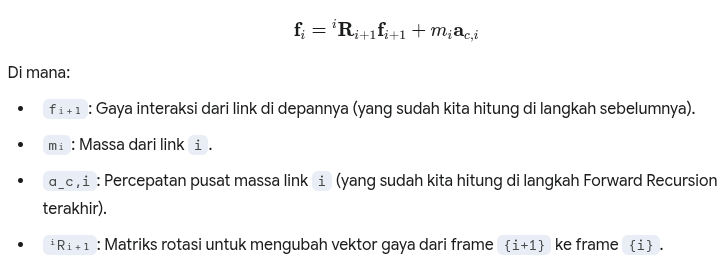

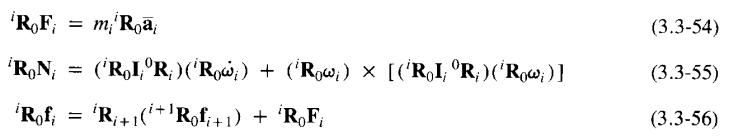

In [ ]:
# Langkah 5: Backward Recursion - Menghitung Gaya Interaksi (f)
# -------------------------------------------------------------------
# Bagian 5: Mendefinisikan Parameter Dinamik (Massa)
# -------------------------------------------------------------------
# Definisikan massa untuk setiap link dari file URDF myCobot
m1 = 0.33
m2 = 0.19
m3 = 0.16
m4 = 0.124
m5 = 0.11
m6 = 0.0739

# -------------------------------------------------------------------
# Bagian 6: Backward Recursion - Perhitungan Gaya (f)
# -------------------------------------------------------------------

# Kondisi Awal di Ujung (End-Effector)
# Asumsi tidak ada gaya atau torsi eksternal yang bekerja pada end-effector
f7 = sp.Matrix([0, 0, 0])
n7 = sp.Matrix([0, 0, 0])

# --- Iterasi i = 6 (Mundur) ---
# Rumus: f_i = i_R_i+1 * f_i+1 + m_i * a_c_i
f6 = R65.T * f7 + m6 * a_c6  # Menggunakan R56.T yang sama dengan R65

# --- Iterasi i = 5 ---
f5 = R54.T * f6 + m5 * a_c5

# --- Iterasi i = 4 ---
f4 = R43.T * f5 + m4 * a_c4

# --- Iterasi i = 3 ---
f3 = R32.T * f4 + m3 * a_c3

# --- Iterasi i = 2 ---
f2 = R21.T * f3 + m2 * a_c2

# --- Iterasi i = 1 ---
f1 = R10.T * f2 + m1 * a_c1

print("="*15 + " GAYA INTERAKSI (f) " + "="*16)
print("f6 (Gaya pada Link 6 dari Link 5):")
sp.pprint(f6.subs(subs_dict))
print("-" * 50)

print("f1 (Gaya pada Link 1 dari Dasar Robot):")
sp.pprint(f1.subs(subs_dict))
print("-" * 50)

=============== GAYA INTERAKSI (f) ================
f6 (Gaya pada Link 6 dari Link 5):
⎡                                                                              ↪
⎢0.0028082⋅C₆⋅(-C₄⋅(C₃⋅(-C₂⋅θ̈1 + S₂⋅θ̇1⋅θ̇2) + S₃⋅(C₂⋅θ̇1⋅θ̇2 + S₂⋅θ̈1) + θ̇3⋅(C₂⋅S₃ ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢0.0028082⋅C₆⋅(C₅⋅(θ̈2 + θ̈3 + θ̈4) - S₅⋅(-C₄⋅(C₃⋅(C₂⋅θ̇1⋅θ̇2 + S₂⋅θ̈1) - S₃⋅(-C₂⋅θ̈1 ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎣                                                                              ↪

↪                                                                              ↪
↪ ⋅θ̇1 + C₃⋅S₂⋅θ̇1)) - S₄⋅(C₃⋅(C₂⋅θ̇1⋅θ̇2 + S₂⋅θ̈1) - S₃⋅(-C₂⋅θ̈1 + S₂⋅θ̇1⋅θ̇2) - θ̇3⋅( ↪
↪                                                                              

### Menghitung Nilai Gaya Inersia (F) dan Torsi Inersia (N)

Perhitungan dilakukan untuk menginisialisasi variabel F dan N

In [ ]:
# Tensor Inersia (didefinisikan sebagai matriks diagonal untuk simplifikasi)
I1=sp.diag(0.000784, 0.000867, 0.001598)
I2=sp.diag(0.000148, 0.000148, 9.6e-05)
I3=sp.diag(0.000148, 0.000148, 9.6e-05)
I4=sp.diag(0.000103, 0.000103, 9.6e-05)
I5=sp.diag(0.000103, 0.000103, 9.6e-05)
I6=sp.diag(6.649e-05, 6.649e-05, 9.6e-05)

# i=6
F6=m6*a_c6; 
N6=I6*alpha6+w6.cross(I6*w6)

# i=5
F5=m5*a_c5; 
N5=I5*alpha5+w5.cross(I5*w5)

# i=4
F4=m4*a_c4; 
N4=I4*alpha4+w4.cross(I4*w4)

# i=3
F3=m3*a_c3; 
N3=I3*alpha3+w3.cross(I3*w3)

# i=2
F2=m2*a_c2; 
N2=I2*alpha2+w2.cross(I2*w2)

# i=1
F1=m1*a_c1; 
N1=I1*alpha1+w1.cross(I1*w1)


# -------------------------------------------------------------------
# Bagian 4: Menampilkan Hasil Akhir (Torsi Sendi)
# -------------------------------------------------------------------
print("="*17 + " Gaya Inersia (F) dan Torsi Inersia (N) " + "="*18)

# Kita gunakan sp.trigsimp untuk menyederhanakan sebelum substitusi
# Ini akan menghasilkan ekspresi yang lebih pendek dan bersih

print("\nF6 (Gaya Inersia pada Link 6):")
sp.pprint(sp.trigsimp(F6).subs(subs_dict))

print("\nN6 (Torsi Inersia pada Link 6):")
sp.pprint(sp.trigsimp(N6).subs(subs_dict))


================= Gaya Inersia (F) dan Torsi Inersia (N) ==================

F6 (Gaya Inersia pada Link 6):
⎡                                                                              ↪
⎢0.0028082⋅C₆⋅(-θ̇1⋅θ̇2⋅sin(θ₂ + θ₃ + θ₄) - θ̇1⋅θ̇3⋅sin(θ₂ + θ₃ + θ₄) - θ̇1⋅θ̇4⋅sin( ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢0.0028082⋅C₆⋅(C₅⋅(θ̈2 + θ̈3 + θ̈4) + S₅⋅(θ̇1⋅θ̇2⋅cos(θ₂ + θ₃ + θ₄) + θ̇1⋅θ̇3⋅cos(θ₂  ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎣                                                                              ↪

↪                                                        ⎛                     ↪
↪ θ₂ + θ₃ + θ₄) + θ̈1⋅cos(θ₂ + θ₃ + θ₄) + θ̈5) + 0.0739⋅C₆⋅⎝0.0456⋅C₄⋅(θ̇1⋅θ̇2⋅sin ↪
↪                                                               

### Menghitung Torsi Interaksi (n)

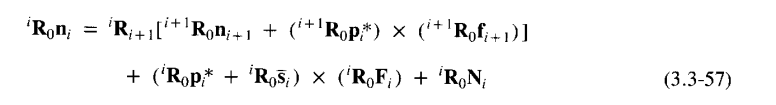

In [ ]:
# i=6
n6=R65.T*n7+p56.cross(R65.T*f7)+s6.cross(F6)+N6
# i=5
n5=R54.T*n6+p45.cross(R54.T*f6)+s5.cross(F5)+N5
# i=4
n4=R43.T*n5+p34.cross(R43.T*f5)+s4.cross(F4)+N4
# i=3
n3=R32.T*n4+p23.cross(R32.T*f4)+s3.cross(F3)+N3
# i=2
n2=R21.T*n3+p12.cross(R21.T*f3)+s2.cross(F2)+N2
# i=1
n1=R10.T*n2+p01.cross(R10.T*f2)+s1.cross(F1)+N1

# -------------------------------------------------------------------
# Bagian 4: Menampilkan Hasil Akhir (Torsi Sendi)
# -------------------------------------------------------------------
print("="*17 + " TORSI INTERAKSI (τ) " + "="*18)

# Kita gunakan sp.trigsimp untuk menyederhanakan sebelum substitusi
# Ini akan menghasilkan ekspresi yang lebih pendek dan bersih

# print("\nn6 (Torsi Interaksi 6):")
# sp.pprint(sp.trigsimp(n6).subs(subs_dict))

# print("\nn1 (Torsi Interaksi 1):")
# sp.pprint(sp.trigsimp(n1).subs(subs_dict))


================= TORSI INTERAKSI (τ) ==================


### Menghitung Joint Torque

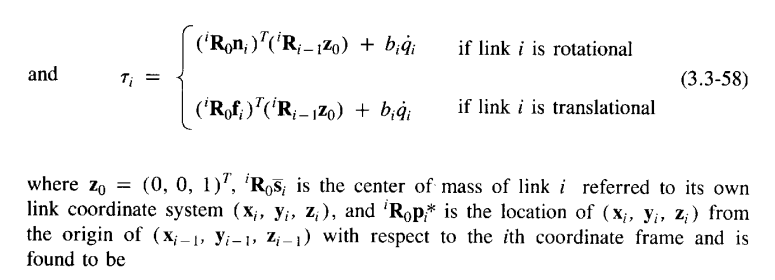

In [ ]:
# -------------------------------------------------------------------
# Bagian 9: Menghitung Torsi Aktuator (τ)
# -------------------------------------------------------------------
# Rumus: τ_i = n_i^T * z_0 (dot product dengan sumbu z)
# Ini mengekstrak komponen z dari vektor torsi interaksi n_i.

tau1 = (n1.T * z0)[0]
tau2 = (n2.T * z0)[0]
tau3 = (n3.T * z0)[0]
tau4 = (n4.T * z0)[0]
tau5 = (n5.T * z0)[0]
tau6 = (n6.T * z0)[0]

print("="*17 + " TORSI AKTUATOR (τ) " + "="*18)
print("\nτ₁ (Torsi Sendi 1):")
sp.pprint(sp.trigsimp(tau1).subs(subs_dict))

================= TORSI AKTUATOR (τ) ==================

τ₁ (Torsi Sendi 1):
